In [47]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [48]:
col_dtype = {
    'Agency':"category",
    'Agency Name':"category",
    'Problem (formerly Complaint Type)':"category",
    'Problem Detail (formerly Descriptor)':"category",
    'Additional Details':"category",       
    'Location Type': "category",
    'Incident Zip':object}
col_dates = ['Created Date', 'Closed Date']

In [49]:
df = pd.read_csv('data/311_Service_Requests_from_2020_to_Present_20260326.csv', dtype=col_dtype, parse_dates=col_dates)

C:\Users\story\AppData\Local\Temp\ipykernel_38816\2912278052.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('data/311_Service_Requests_from_2020_to_Present_20260326.csv', dtype=col_dtype, parse_dates=col_dates)
C:\Users\story\AppData\Local\Temp\ipykernel_38816\2912278052.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('data/311_Service_Requests_from_2020_to_Present_20260326.csv', dtype=col_dtype, parse_dates=col_dates)


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142088 entries, 0 to 142087
Data columns (total 44 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   Unique Key                            142088 non-null  int64         
 1   Created Date                          142088 non-null  datetime64[us]
 2   Closed Date                           137542 non-null  datetime64[us]
 3   Agency                                142088 non-null  category      
 4   Agency Name                           142088 non-null  category      
 5   Problem (formerly Complaint Type)     142088 non-null  category      
 6   Problem Detail (formerly Descriptor)  142088 non-null  category      
 7   Additional Details                    142088 non-null  category      
 8   Location Type                         112925 non-null  category      
 9   Incident Zip                          141459 non-null  object        


In [51]:
df.dropna(how='all', axis=1, inplace=True)

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142088 entries, 0 to 142087
Data columns (total 35 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   Unique Key                            142088 non-null  int64         
 1   Created Date                          142088 non-null  datetime64[us]
 2   Closed Date                           137542 non-null  datetime64[us]
 3   Agency                                142088 non-null  category      
 4   Agency Name                           142088 non-null  category      
 5   Problem (formerly Complaint Type)     142088 non-null  category      
 6   Problem Detail (formerly Descriptor)  142088 non-null  category      
 7   Additional Details                    142088 non-null  category      
 8   Location Type                         112925 non-null  category      
 9   Incident Zip                          141459 non-null  object        


In [53]:
df.groupby('Borough').describe(include=['category']).T

Borough                                                                             BRONX  \
Agency                               count                                          23629   
                                     unique                                             2   
                                     top                                             DCWP   
                                     freq                                           17966   
Agency Name                          count                                          23629   
                                     unique                                             2   
                                     top     Department of Consumer and Worker Protection   
                                     freq                                           17966   
Problem (formerly Complaint Type)    count                                          23629   
                                     unique                                             1   
                                     top                               Consumer Complaint   
                                     freq                                           23629   
Problem Detail (formerly Descriptor) count                                          23629   
                                     unique                                           111   
                                     top                                     Retail Store   
                                     freq                                            5940   
Additional Details                   count                                          23629   
                                     unique                                           162   
                                     top                                       Overcharge   
                                     freq                                            6562   
Location Type                        count                                          17411   
                                     unique                                             2   
                                     top                                         Business   
                                     freq                                           15171   

Borough                                                                          BROOKLYN  \
Agency                               count                                          39527   
                                     unique                                             2   
                                     top                                             DCWP   
                                     freq                                           31407   
Agency Name                          count                                          39527   
                                     unique                                             2   
                                     top     Department of Consumer and Worker Protection   
                                     freq                                           31407   
Problem (formerly Complaint Type)    count                                          39527   
                                     unique                                             1   
                                     top                               Consumer Complaint   
                                     freq                                           39527   
Problem Detail (formerly Descriptor) count                                          39527   
                                     unique                                           124   
                                     top                                     Retail Store   
                                     freq                                            9588   
Additional Details                   count                                          39527   


In [54]:
ctable = df.pivot_table(values='Additional Details', index='Borough', columns=['Problem Detail (formerly Descriptor)'], aggfunc='count').T
ctable


Borough,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,Unspecified
Problem Detail (formerly Descriptor),,,,,,
Airline,NaN,1.0,1.0,7.0,1.0,NaN
Arcade,7.0,20.0,18.0,4.0,2.0,NaN
Art Supply Store,NaN,11.0,25.0,2.0,1.0,NaN
Auction House or Auctioneer,1.0,9.0,6.0,9.0,1.0,NaN
Automated Employment Decision Tool Use,NaN,3.0,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...
Amusement Ride,2.0,9.0,3.0,5.0,5.0,NaN
Cabaret,NaN,1.0,NaN,NaN,NaN,NaN
Going Out of Business,NaN,2.0,4.0,3.0,NaN,NaN


<Axes: ylabel='Problem Detail (formerly Descriptor)'>

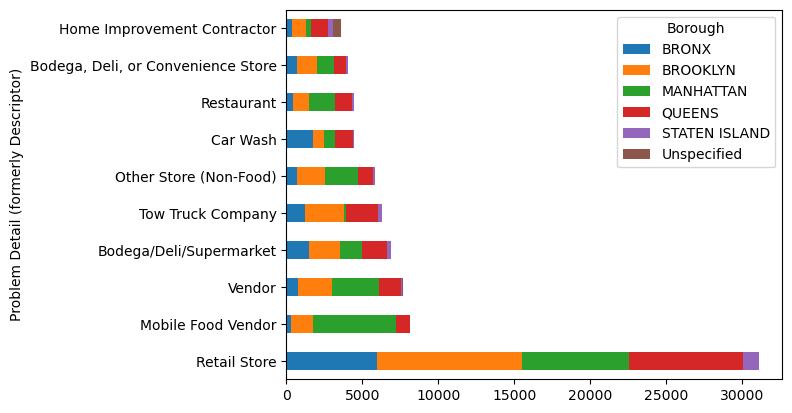

In [55]:
ctable.loc[ctable.sum(axis=1).sort_values(ascending=False).index[:10]].plot.barh(stacked=True)

<Axes: xlabel='Problem Detail (formerly Descriptor)'>

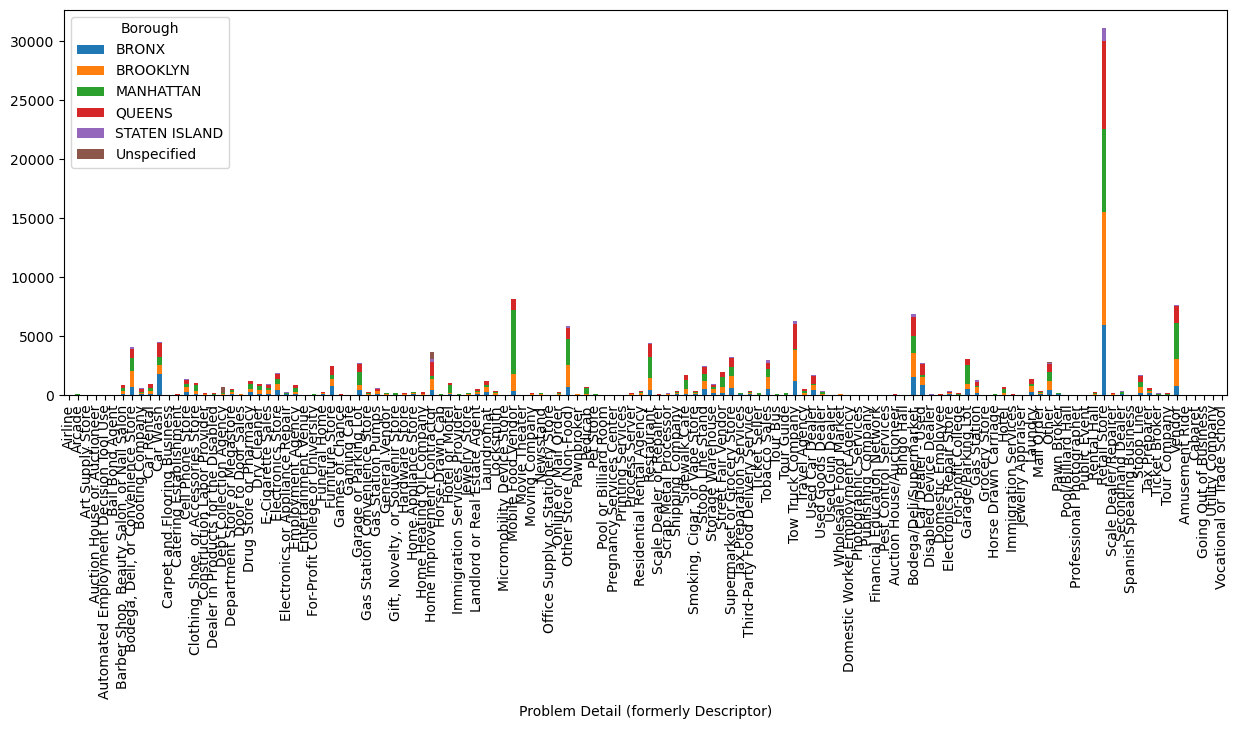

In [58]:
ctable.plot.bar(stacked='True', figsize=(15, 5))

In [59]:
ctable.index

CategoricalIndex(['Airline', 'Arcade', 'Art Supply Store',
                  'Auction House or Auctioneer',
                  'Automated Employment Decision Tool Use', 'Bail Bond Agent',
                  'Barber Shop, Beauty Salon, or Nail Salon',
                  'Bodega, Deli, or Convenience Store', 'Booting Company',
                  'Car Rental',
                  ...
                  'Stoop Line', 'Tax Preparer', 'Ticket Broker',
                  'Tour Company', 'Vendor', 'Amusement Ride', 'Cabaret',
                  'Going Out of Business', 'Utility Company',
                  'Vocational or Trade School'],
                 categories=['Airline', 'Arcade', 'Art Supply Store', 'Auction House or Auctioneer', ..., 'Cabaret', 'Going Out of Business', 'Utility Company', 'Vocational or Trade School'], ordered=False, dtype='category', name='Problem Detail (formerly Descriptor)', length=128)

In [60]:
gdf = gpd.read_file("data/2020_Census_Tracts_20260326.geojson")

In [61]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   :id          2325 non-null   str                
 1   :version     2325 non-null   str                
 2   :created_at  2325 non-null   datetime64[ms, UTC]
 3   :updated_at  2325 non-null   datetime64[ms, UTC]
 4   ctlabel      2325 non-null   str                
 5   borocode     2325 non-null   str                
 6   boroname     2325 non-null   str                
 7   ct2020       2325 non-null   str                
 8   boroct2020   2325 non-null   str                
 9   cdeligibil   2325 non-null   str                
 10  ntaname      2325 non-null   str                
 11  nta2020      2325 non-null   str                
 12  cdta2020     2325 non-null   str                
 13  cdtaname     2325 non-null   str                
 14  geoid        232

<Axes: >

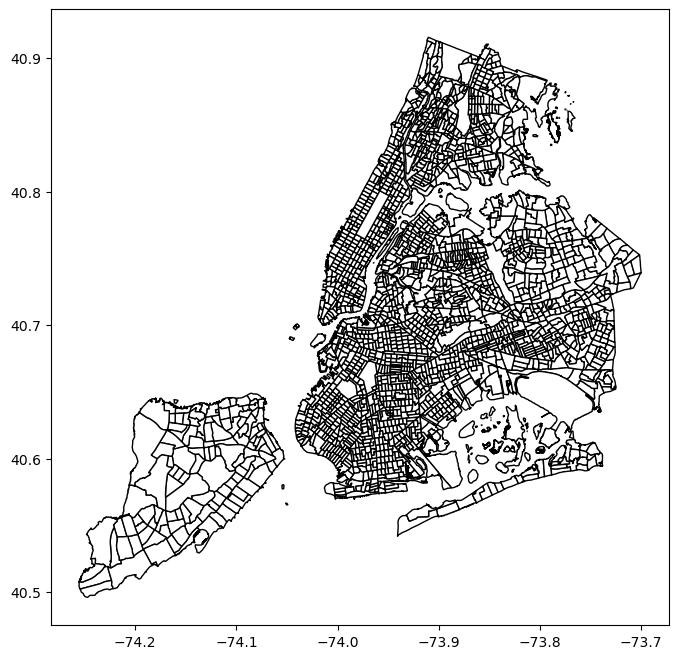

In [62]:
gdf.plot(facecolor='w', edgecolor='k', figsize=(10,8))

In [63]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   :id          2325 non-null   str                
 1   :version     2325 non-null   str                
 2   :created_at  2325 non-null   datetime64[ms, UTC]
 3   :updated_at  2325 non-null   datetime64[ms, UTC]
 4   ctlabel      2325 non-null   str                
 5   borocode     2325 non-null   str                
 6   boroname     2325 non-null   str                
 7   ct2020       2325 non-null   str                
 8   boroct2020   2325 non-null   str                
 9   cdeligibil   2325 non-null   str                
 10  ntaname      2325 non-null   str                
 11  nta2020      2325 non-null   str                
 12  cdta2020     2325 non-null   str                
 13  cdtaname     2325 non-null   str                
 14  geoid        232

In [64]:
xy311 = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs="EPSG:4326")

In [65]:
xy311

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Open Data Channel Type,Park Facility Name,Park Borough,Latitude,Longitude,Location,geometry
0,68444577,2026-03-24 23:09:36,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,"Bodega, Deli, or Convenience Store",Credit Card Total Price Not Posted,Business,10034,...,MANHATTAN,"1,005,437","255,129",ONLINE,Unspecified,MANHATTAN,40.866919,-73.923398,POINT (-73.923398297628 40.866919326707),POINT (-73.9234 40.86692)
1,68444545,2026-03-24 22:42:46,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,"Smoking, Cigar, or Vape Store",Advertising False or Misleading,Business,10029,...,MANHATTAN,"1,000,267","228,936",PHONE,Unspecified,MANHATTAN,40.795038,-73.942153,POINT (-73.942152989756 40.795037973078),POINT (-73.94215 40.79504)
2,68435251,2026-03-24 22:27:36,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Supermarket or Grocery Store,Overcharge,Business,11207,...,BROOKLYN,"1,013,417","181,431",ONLINE,Unspecified,BROOKLYN,40.664615,-73.894866,POINT (-73.894866390425 40.664614867715),POINT (-73.89487 40.66461)
3,68439839,2026-03-24 22:23:42,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Third-Party Food Delivery Service,Goods or Services Not Delivered,Business,11354,...,QUEENS,"1,031,788","218,799",ONLINE,Unspecified,QUEENS,40.767101,-73.828384,POINT (-73.828383641347 40.767101295681),POINT (-73.82838 40.7671)
4,68441482,2026-03-24 22:17:53,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Ticket Seller,Unlicensed,Business,11378,...,QUEENS,"1,011,718","204,768",ONLINE,Unspecified,QUEENS,40.728675,-73.900895,POINT (-73.900895328366 40.728674896623),POINT (-73.9009 40.72867)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142083,45285527,2020-01-01 13:20:33,2020-12-23 22:59:19,DCA,Department of Consumer Affairs,Consumer Complaint,Retail Store,Damaged/Defective Goods,NaN,11377,...,QUEENS,"1,007,870","209,873",PHONE,Unspecified,QUEENS,40.742698,-73.914761,POINT (-73.914760997771 40.742697967501),POINT (-73.91476 40.7427)
142084,45287009,2020-01-01 13:09:15,2020-12-23 22:59:18,DCA,Department of Consumer Affairs,Consumer Complaint,Retail Store,Damaged/Defective Goods,NaN,11226,...,BROOKLYN,"996,813","174,188",PHONE,Unspecified,BROOKLYN,40.644774,-73.954730,POINT (-73.954729642463 40.644773547559),POINT (-73.95473 40.64477)
142085,45287364,2020-01-01 12:22:48,2020-01-02 11:04:07,DCA,Department of Consumer Affairs,Consumer Complaint,Bodega/Deli/Supermarket,Cigarette Sale to Minor,NaN,11432,...,QUEENS,"1,038,968","197,197",PHONE,Unspecified,QUEENS,40.707768,-73.802639,POINT (-73.802638996384 40.707767778731),POINT (-73.80264 40.70777)
142086,45285624,2020-01-01 08:16:36,2020-01-02 14:04:32,DCA,Department of Consumer Affairs,Consumer Complaint,Restaurant,Overcharge,NaN,10121,...,MANHATTAN,"986,437","212,546",PHONE,Unspecified,MANHATTAN,40.750066,-73.992107,POINT (-73.992106761776 40.750065954212),POINT (-73.99211 40.75007)


In [66]:
geo311 = gdf.sjoin(xy311, how='inner', predicate='contains', lsuffix='311')

In [67]:
overcharges = geo311[geo311['Problem Detail (formerly Descriptor)'].str.match('Retail Store') & geo311['Additional Details'].str.match('Overcharge')]       

<Axes: >

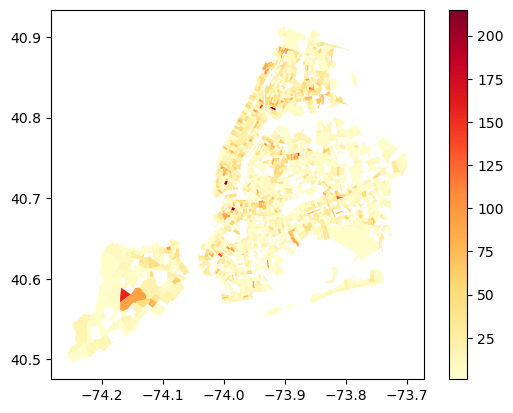

In [68]:
overcharges.dissolve(by='ct2020', aggfunc='count').plot(column='Unique Key', cmap='YlOrRd', legend=True)

<Axes: label='map'>

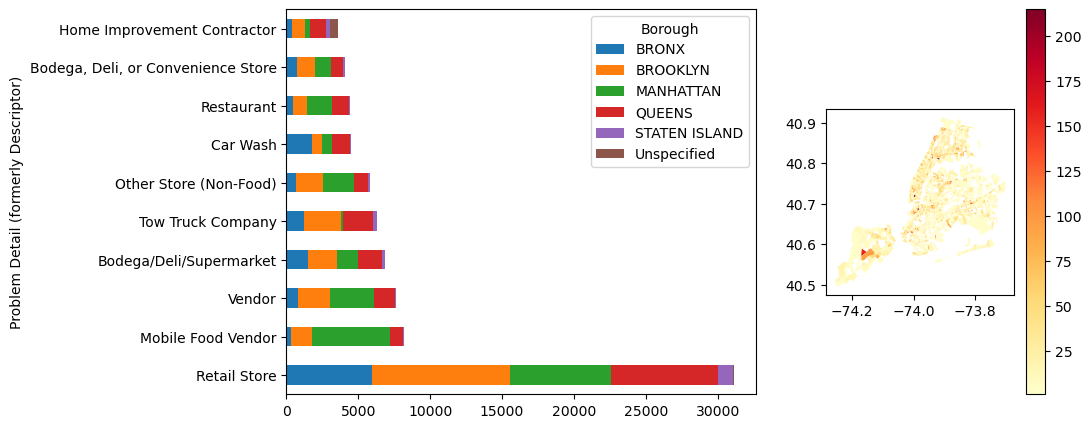

In [69]:
fig, axd = plt.subplot_mosaic([['bar', 'map']], figsize=(10,5), width_ratios=[2,1])
ctable.loc[ctable.sum(axis=1).sort_values(ascending=False).index[:10]].plot.barh(stacked=True, ax=axd['bar'])
overcharges.dissolve(by='ct2020', aggfunc='count').plot(column='Unique Key', cmap='YlOrRd', legend=True, ax = axd['map'])

<Axes: label='bar', ylabel='Problem Detail (formerly Descriptor)'>

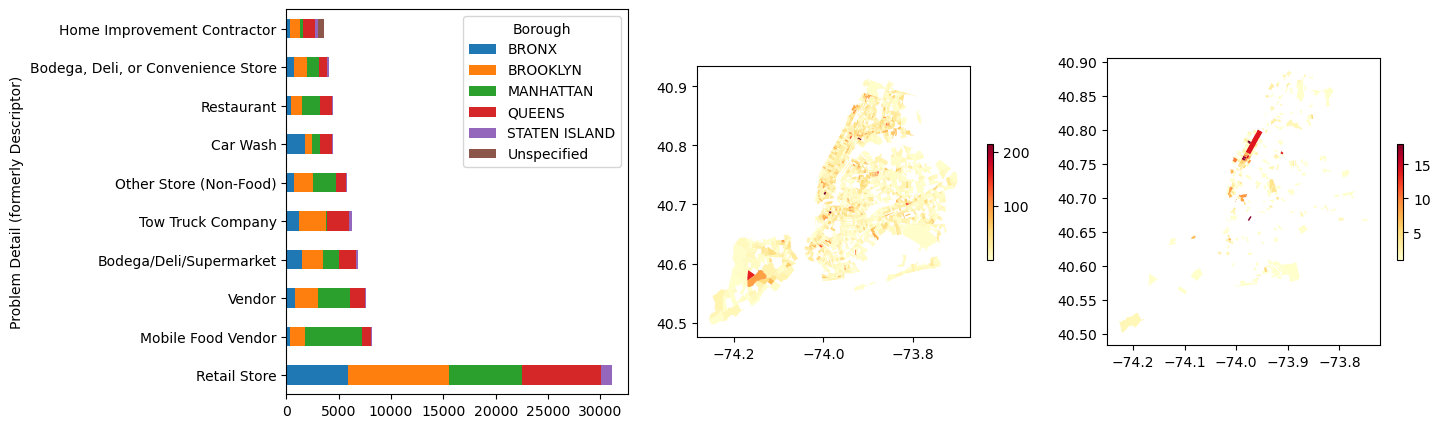

In [70]:
fig, axd = plt.subplot_mosaic([['bar', 'map1', 'map2']], figsize=(15,5))
overcharges.dissolve(by='ct2020', aggfunc='count').plot(column='Unique Key', cmap='YlOrRd', legend=True, ax=axd['map1'], legend_kwds={'shrink':.3})
vendors = geo311[geo311['Problem Detail (formerly Descriptor)'].str.contains('vendor', case=False) & geo311['Additional Details'].str.match('Overcharge')]  
vendors.dissolve(by='ct2020', aggfunc='count').plot(column='Unique Key', cmap='YlOrRd', legend=True, ax=axd['map2'], legend_kwds={'shrink':.3})
ctable.loc[ctable.sum(axis=1).sort_values(ascending=False).index[:10]].plot.barh(stacked=True, ax=axd['bar'])

Text(0.5, 1.0, '??')

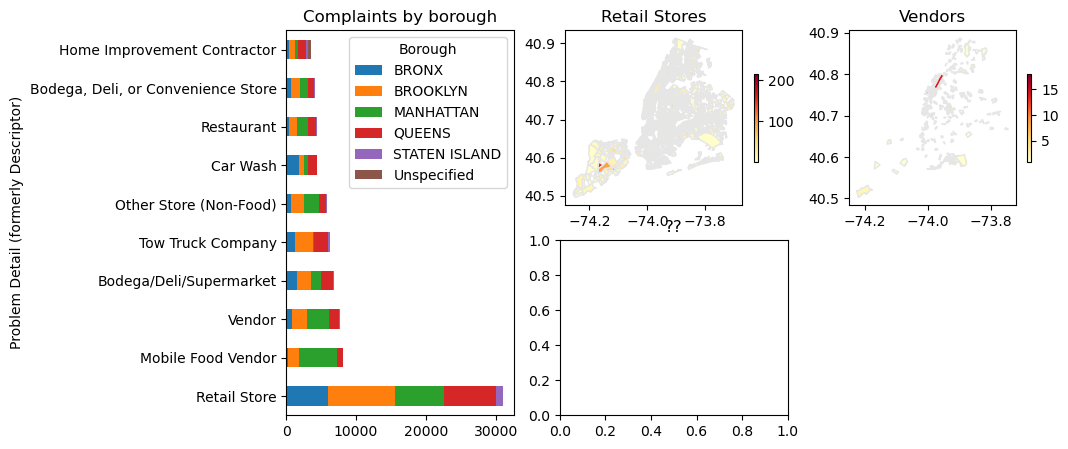

In [73]:
fig, axd = plt.subplot_mosaic([['bar', 'map1', 'map2'], ['bar', 'map3', '.']], figsize=(10,5))
overcharges.dissolve(by='ct2020', aggfunc='count').plot(column='Unique Key', cmap='YlOrRd', legend=True, ax=axd['map1'],  legend_kwds={'shrink':.5}, edgecolor='.9')
vendors = geo311[geo311['Problem Detail (formerly Descriptor)'].str.contains('vendor', case=False) & geo311['Additional Details'].str.match('Overcharge')]  
vendors.dissolve(by='ct2020', aggfunc='count').plot(column='Unique Key', cmap='YlOrRd', legend=True, ax=axd['map2'],  legend_kwds={'shrink':.5}, edgecolor='.9')
barax = ctable.loc[ctable.sum(axis=1).sort_values(ascending=False).index[:10]].plot.barh(stacked=True, ax=axd['bar'])
axd['bar'].set_title("Complaints by borough")
axd['map1'].set_title("Retail Stores")
axd['map2'].set_title("Vendors")
axd['map3'].set_title("??")

Text(0.5, 1.0, '??')

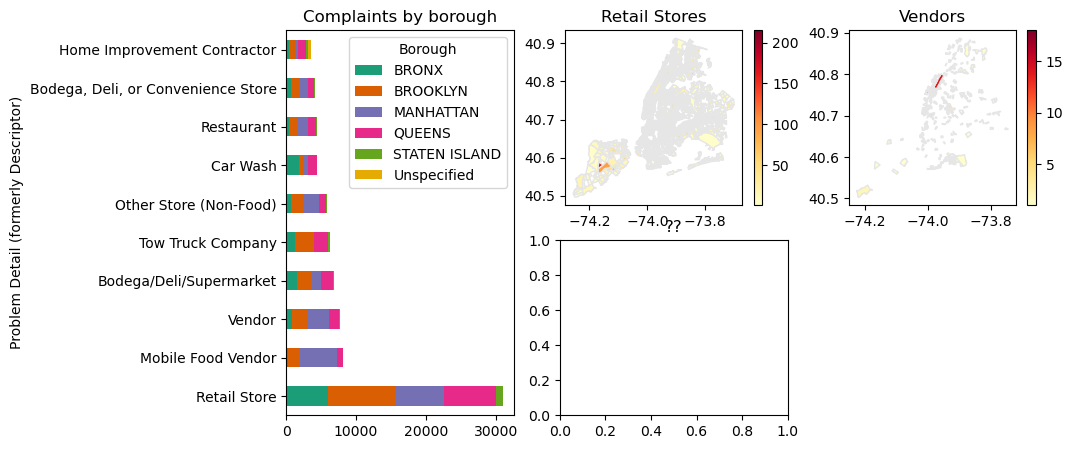

In [83]:
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02']
fig, axd = plt.subplot_mosaic([['bar', 'map1', 'map2'], ['bar', 'map3', '.']], figsize=(10,5))
overcharges.dissolve(by='ct2020', aggfunc='count').plot(column='Unique Key', cmap='YlOrRd', legend=True, ax=axd['map1'],  legend_kwds={'shrink':1}, edgecolor='.9')
vendors = geo311[geo311['Problem Detail (formerly Descriptor)'].str.contains('vendor', case=False) & geo311['Additional Details'].str.match('Overcharge')]  
vendors.dissolve(by='ct2020', aggfunc='count').plot(column='Unique Key', cmap='YlOrRd', legend=True, ax=axd['map2'],  legend_kwds={'shrink':1}, edgecolor='.9')
barax = ctable.loc[ctable.sum(axis=1).sort_values(ascending=False).index[:10]].plot.barh(stacked=True, ax=axd['bar'], color=colors)
axd['bar'].set_title("Complaints by borough")
axd['map1'].set_title("Retail Stores")
axd['map2'].set_title("Vendors")
axd['map3'].set_title("??")

In [85]:
geo311.to_file("data/geolocated311.json")